In [ ]:
FUSION AREAS B1-B4

In [5]:
import rasterio
from rasterio.merge import merge
import os

# 1. Definir los archivos base (rasterio buscará automáticamente los .hdr)
archivos_bil = [
    'e14b49b1_mt.bil',
    'e14b49b2_mt.bil',
    'e14b49b3_mt.bil',
    'e14b49b4_mt.bil'
]

src_files_to_mosaic = []

try:
    print("Iniciando lectura de archivos del CEM (1.5m)...")
    for nombre in archivos_bil:
        if os.path.exists(nombre):
            src = rasterio.open(nombre)
            src_files_to_mosaic.append(src)
            # Imprimir resolución para confirmar que es la de 1.5m
            res_x, res_y = src.res
            print(f"✅ {nombre} cargado. Resolución detectada: {res_x}m x {res_y}m")
        else:
            print(f"❌ Error: No se encontró {nombre}")

    if len(src_files_to_mosaic) == 4:
        print("\nGenerando mosaico unificado de las 4 áreas...")
        # 2. Fusionar los rásters
        mosaic, out_trans = merge(src_files_to_mosaic)

        # 3. Preparar metadatos para la salida en formato GeoTIFF
        out_meta = src_files_to_mosaic[0].meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "height": mosaic.shape[1],
            "width": mosaic.shape[2],
            "transform": out_trans,
            "crs": src_files_to_mosaic[0].crs,
            "nodata": src_files_to_mosaic[0].nodata
        })

        # 4. Guardar el archivo conjunto
        output_filename = "CEM_Veracruz_Mosaico_1_5m.tif"
        with rasterio.open(output_filename, "w", **out_meta) as dest:
            dest.write(mosaic)

        print(f"\n¡Éxito! El archivo conjunto se ha generado: {output_filename}")
        print(f"Dimensiones finales: {mosaic.shape[2]} x {mosaic.shape[1]} píxeles.")
    else:
        print("\nError: No se cargaron los 4 archivos necesarios.")

except Exception as e:
    print(f"\nOcurrió un error: {e}")

finally:
    # Cerrar conexiones para liberar memoria RAM
    for src in src_files_to_mosaic:
        src.close()

Iniciando lectura de archivos del CEM (1.5m)...
✅ e14b49b1_mt.bil cargado. Resolución detectada: 1.5m x 1.5m
✅ e14b49b2_mt.bil cargado. Resolución detectada: 1.5m x 1.5m
✅ e14b49b3_mt.bil cargado. Resolución detectada: 1.5m x 1.5m
✅ e14b49b4_mt.bil cargado. Resolución detectada: 1.5m x 1.5m

Generando mosaico unificado de las 4 áreas...


/usr/local/lib/python3.12/dist-packages/rasterio/merge.py:369: UserWarning: Ignoring nodata value. The nodata value, -3.4028231e+38, cannot safely be represented in the chosen data type, float32. Consider overriding it using the --nodata option for better results. Falling back to first source's nodata value.
  warnings.warn(



¡Éxito! El archivo conjunto se ha generado: CEM_Veracruz_Mosaico_1_5m.tif
Dimensiones finales: 8012 x 9423 píxeles.


Segmentación y Extracción de Elevación

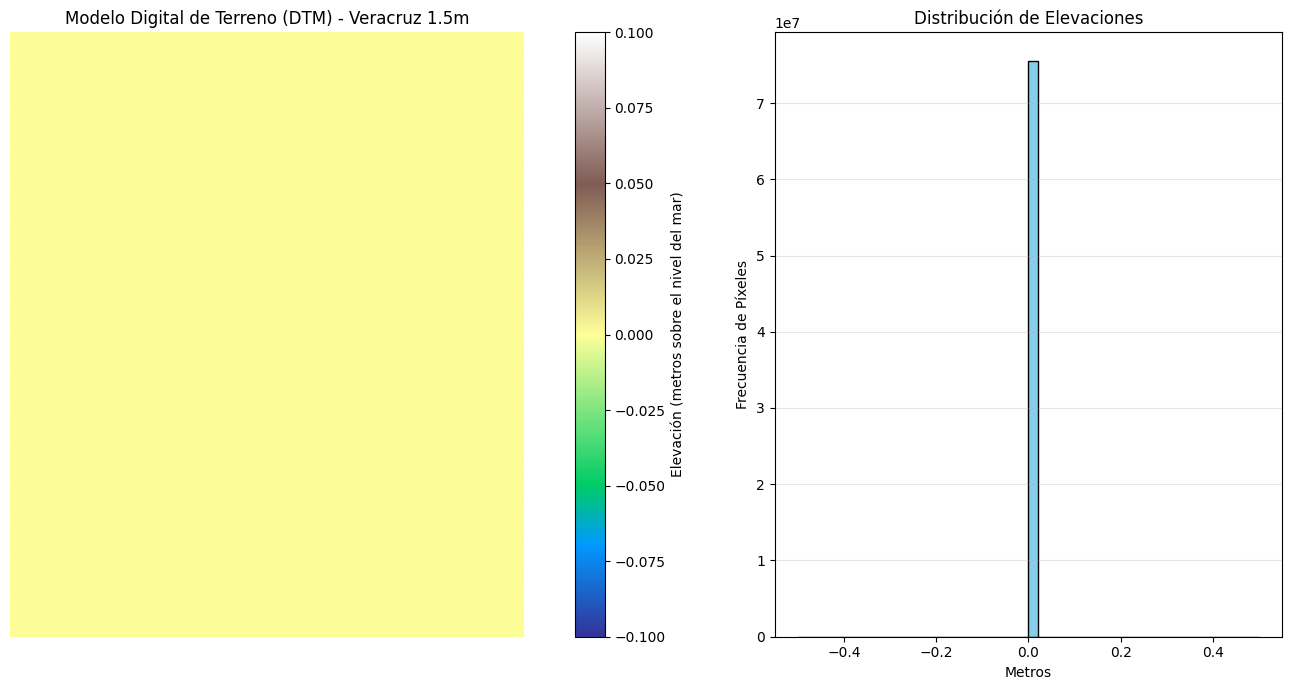

--- Estadísticas de Elevación del Puerto ---
Elevación Mínima: 0.00 m
Elevación Máxima: 0.00 m
Elevación Media:  0.00 m


In [8]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar el mosaico unificado de 1.5m
archivo_mosaico = 'CEM_Veracruz_Mosaico_1_5m.tif'

with rasterio.open(archivo_mosaico) as src:
    # Leer la banda 1 (elevación)
    elevation = src.read(1)

    # Reemplazar valores 'nodata' por NaN para una visualización limpia
    # El CEM de 1.5m usa valores muy bajos (como -3.402e+38) para el mar/vacío
    elevation = np.where(elevation < -100, np.nan, elevation)

    # 2. Configurar la visualización
    fig, (ax_map, ax_hist) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2, 1]})

    # Mapa de Elevación con barra de colores
    # 'terrain' es ideal para topografía; 'magma' o 'viridis' son buenos para resaltar contrastes
    img = ax_map.imshow(elevation, cmap='terrain')
    fig.colorbar(img, ax=ax_map, label='Elevación (metros sobre el nivel del mar)')
    ax_map.set_title('Modelo Digital de Terreno (DTM) - Veracruz 1.5m')
    ax_map.axis('off')

    # Histograma de elevaciones (útil para identificar zonas bajas de riesgo)
    # Filtramos NaN y valores extremos para el histograma
    flat_elev = elevation[~np.isnan(elevation)]
    ax_hist.hist(flat_elev, bins=50, color='skyblue', edgecolor='black')
    ax_hist.set_title('Distribución de Elevaciones')
    ax_hist.set_xlabel('Metros')
    ax_hist.set_ylabel('Frecuencia de Píxeles')
    ax_hist.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 3. Resumen estadístico para tu reporte de la Etapa E2
    print(f"--- Estadísticas de Elevación del Puerto ---")
    print(f"Elevación Mínima: {np.nanmin(elevation):.2f} m")
    print(f"Elevación Máxima: {np.nanmax(elevation):.2f} m")
    print(f"Elevación Media:  {np.nanmean(elevation):.2f} m")

DIAGNOSTICO DE DATOS INDIVIDUALES

In [9]:
import rasterio
import numpy as np

# Probar con uno de los archivos originales para ver qué está leyendo
with rasterio.open('e14b49b1_mt.bil') as src:
    data = src.read(1)
    print(f"--- Diagnóstico de {src.name} ---")
    print(f"Valores únicos (primeros 10): {np.unique(data)[:10]}")
    print(f"Valor máximo real: {data.max()}")
    print(f"Valor mínimo real: {data.min()}")
    print(f"Tipo de dato (dtype): {src.dtypes[0]}")

--- Diagnóstico de e14b49b1_mt.bil ---
Valores únicos (primeros 10): [-3.402823e+38 -1.490000e+00 -1.480000e+00 -1.470000e+00 -1.460000e+00
 -1.450000e+00 -1.440000e+00 -1.430000e+00 -1.420000e+00 -1.410000e+00]
Valor máximo real: 72.23999786376953
Valor mínimo real: -3.4028230607370965e+38
Tipo de dato (dtype): float32


COMPROBACIÓN DE DATOS INDIVIDUALES

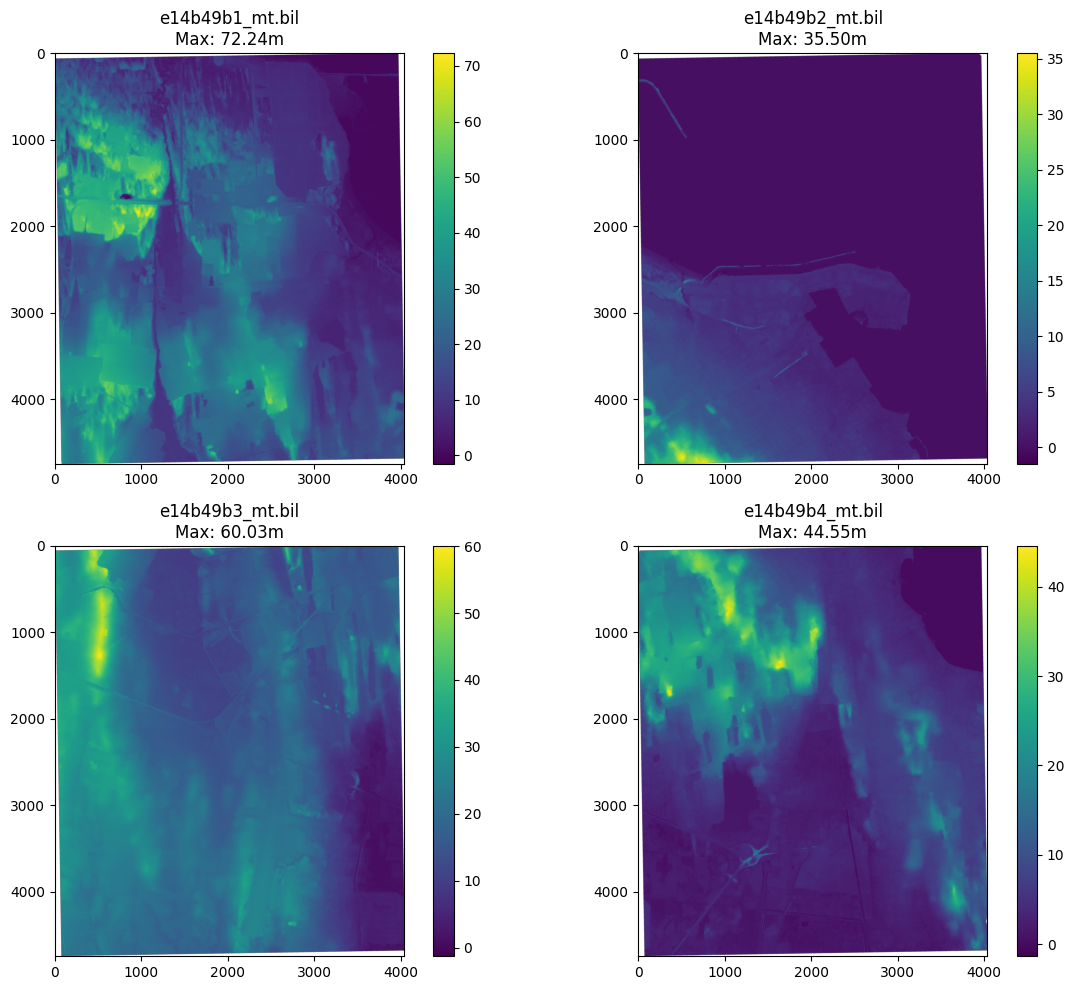

In [12]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

archivos = ['e14b49b1_mt.bil', 'e14b49b2_mt.bil', 'e14b49b3_mt.bil', 'e14b49b4_mt.bil']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, nombre in enumerate(archivos):
    with rasterio.open(nombre) as src:
        # Leemos los datos tal cual
        data = src.read(1)

        # Filtramos solo el valor extremo de NoData para que se vea algo
        nodata = src.nodata
        data_filtered = np.where(data == nodata, np.nan, data)

        # Si sigue saliendo plano, intentamos filtrar cualquier cosa menor a -100
        if np.nanmax(data_filtered) == 0:
            data_filtered = np.where(data < -100, np.nan, data)

        im = axes[i].imshow(data_filtered, cmap='viridis')
        axes[i].set_title(f"{nombre}\nMax: {np.nanmax(data_filtered):.2f}m")
        plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()


FUSION DE 4 MOSAICOS



Iniciando el proceso de fusión para el puerto de Veracruz...

¡Éxito! El archivo conjunto se ha generado: CEM_Veracruz_1_5m_FINAL_merged.tif
Dimensiones finales: 8012 x 9423 píxeles.
Máximo real (excluyendo nodata): 72.24 m
Mínimo real (excluyendo nodata): -1.49 m


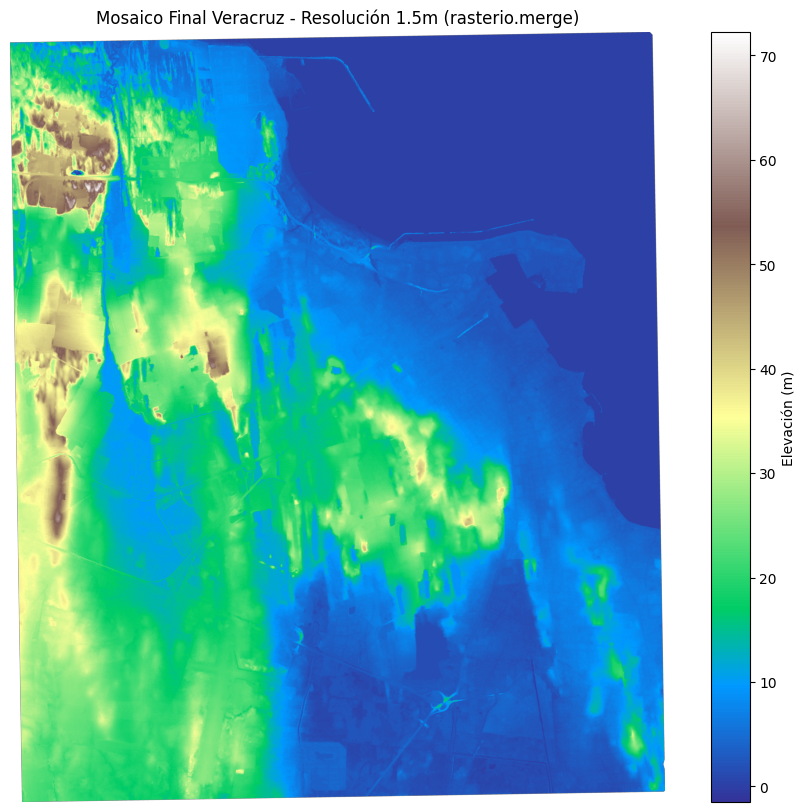

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.merge import merge
import rasterio.crs # Import for CRS

# Definir los archivos que componen el mosaico
archivos_bil = [
    'e14b49b1_mt.bil',
    'e14b49b2_mt.bil',
    'e14b49b3_mt.bil',
    'e14b49b4_mt.bil'
]

src_files = []
output_filename = "CEM_Veracruz_1_5m_FINAL_merged.tif"

print("Iniciando el proceso de fusión para el puerto de Veracruz...")

try:
    # 1. Abrir todos los archivos raster
    for nombre in archivos_bil:
        src_files.append(rasterio.open(nombre))

    # Definir un valor de nodata seguro para float32 que no esté dentro del rango de elevaciones
    # El valor -9999 es comúnmente usado para nodata en DEMs.
    safe_nodata_value = -9999.0

    # 2. Fusionar los rásters usando rasterio.merge
    # Es crucial pasar el parámetro `nodata` y `res` para que el merge maneje correctamente
    # los valores nodata y la resolución si hubiera alguna inconsistencia menor.
    # El CRS se toma del primer archivo, asumiendo que todos están en el mismo CRS.
    mosaic, out_transform = merge(
        src_files,
        nodata=safe_nodata_value,
        # `precision` se puede usar para ajustar la precisión de la alineación
        # `res` se puede especificar si se quiere forzar una resolución particular para el output
    )

    # 3. Limpiar el mosaico: reemplazar el valor nodata por NaN para visualización/cálculos
    # Usamos np.isclose para manejar posibles errores de flotante si el nodata_value
    # no es exactamente igual después de la operación de merge o lecturas.
    mosaic_cleaned = np.where(np.isclose(mosaic, safe_nodata_value), np.nan, mosaic)

    # 4. Preparar metadatos para la salida
    out_meta = src_files[0].meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": mosaic_cleaned.shape[1],
        "width": mosaic_cleaned.shape[2],
        "transform": out_transform,
        "crs": rasterio.crs.CRS.from_epsg(32615), # Asignar CRS explícitamente (UTM Zone 15N, WGS84)
        "nodata": safe_nodata_value, # Usar el valor nodata seguro
        "dtype": 'float32' # Asegurarse de que el tipo de dato sea float32
    })

    # 5. Guardar el archivo conjunto limpio
    with rasterio.open(output_filename, "w", **out_meta) as dest:
        # Convertir NaNs de vuelta a safe_nodata_value antes de guardar
        # Se accede a la primera banda con [0] para que la matriz sea 2D para el método write.
        dest.write(np.nan_to_num(mosaic_cleaned[0], nan=safe_nodata_value).astype('float32'), 1)

    print(f"\n¡Éxito! El archivo conjunto se ha generado: {output_filename}")
    print(f"Dimensiones finales: {mosaic_cleaned.shape[2]} x {mosaic_cleaned.shape[1]} píxeles.")
    print(f"Máximo real (excluyendo nodata): {np.nanmax(mosaic_cleaned):.2f} m")
    print(f"Mínimo real (excluyendo nodata): {np.nanmin(mosaic_cleaned):.2f} m")

    # --- Visualización Inmediata ---
    plt.figure(figsize=(12, 10))
    img = plt.imshow(mosaic_cleaned[0], cmap='terrain', vmin=np.nanmin(mosaic_cleaned), vmax=np.nanmax(mosaic_cleaned))
    plt.colorbar(img, label='Elevación (m)')
    plt.title("Mosaico Final Veracruz - Resolución 1.5m (rasterio.merge)")
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"\nOcurrió un error durante la fusión o el procesamiento: {e}")

finally:
    # Cerrar todas las conexiones a los archivos raster
    for src in src_files:
        src.close()


ALINEACION DE CAPAS


In [2]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import os

def alinear_capas(archivo_maestro, archivo_a_alinear, nombre_salida):
    # Verificar si los archivos existen antes de intentar abrirlos
    if not os.path.exists(archivo_maestro):
        print(f"❌ Error: No se encuentra el archivo maestro '{archivo_maestro}'")
        print(f"Archivos disponibles en tu carpeta: {os.listdir('.')}")
        return

    if not os.path.exists(archivo_a_alinear):
        print(f"❌ Error: No se encuentra '{archivo_a_alinear}' para alinear.")
        return

    with rasterio.open(archivo_maestro) as master:
        master_meta = master.meta.copy()

        with rasterio.open(archivo_a_alinear) as to_align:
            # Crear matriz vacía con dimensiones del maestro
            aligned_data = np.zeros((master.height, master.width), dtype='float32')

            print(f"Alineando {archivo_a_alinear} con la topografía de Veracruz...")

            # Reproyectar para forzar coincidencia de píxeles
            reproject(
                source=rasterio.band(to_align, 1),
                destination=aligned_data,
                src_transform=to_align.transform,
                src_crs=to_align.crs,
                dst_transform=master.transform,
                dst_crs=master.crs,
                resampling=Resampling.nearest
            )

            # Actualizar metadatos para el nuevo archivo
            master_meta.update({
                "driver": "GTiff",
                "dtype": 'float32',
                "count": 1,
                "nodata": 0
            })

            with rasterio.open(nombre_salida, 'w', **master_meta) as dest:
                dest.write(aligned_data, 1)

    print(f"✅ ¡Éxito! Capa alineada guardada como: {nombre_salida}")

# --- EJECUCIÓN ---
# Usamos el nombre exacto que salió en tu proceso exitoso anterior
archivo_topografia = 'CEM_Veracruz_1_5m_FINAL_merged.tif'
archivo_urbano = 'capa_urbana.tif' # Asegúrate de haber subido este archivo

alinear_capas(archivo_topografia, archivo_urbano, 'Capa_Urbana_Alineada.tif')

Alineando capa_urbana.tif con la topografía de Veracruz...
✅ ¡Éxito! Capa alineada guardada como: Capa_Urbana_Alineada.tif


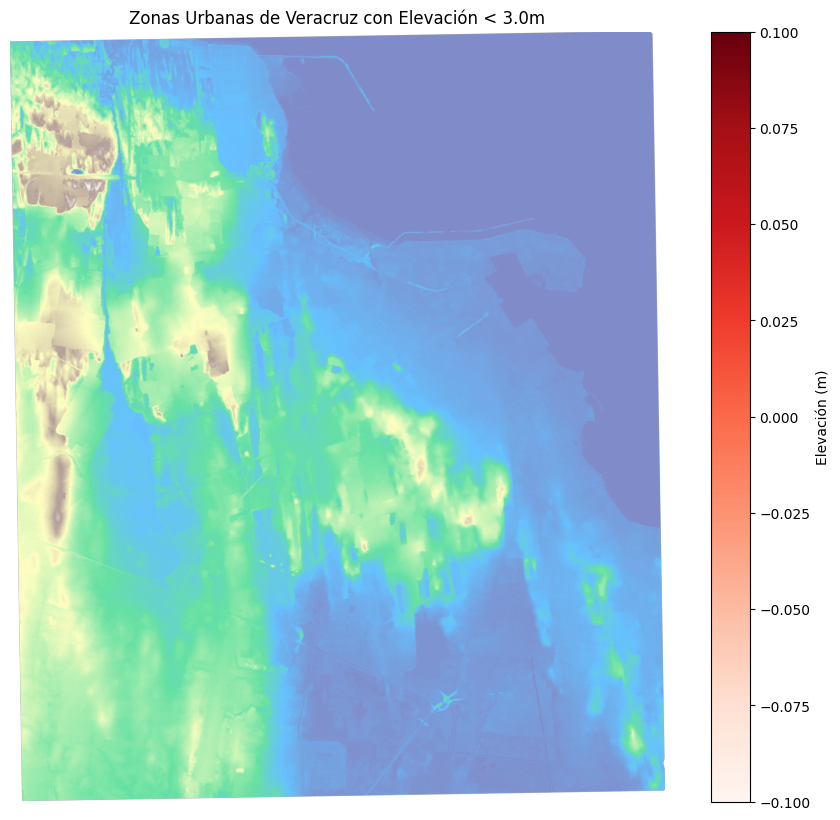

Análisis completado para el puerto de Veracruz.
Áreas detectadas bajo el umbral de 3.0m en zona urbana.


In [3]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar las capas alineadas
with rasterio.open('CEM_Veracruz_1_5m_FINAL_merged.tif') as dem_src:
    dem = dem_src.read(1)
    # Limpiamos valores nulos de la topografía
    dem_cleaned = np.where(dem < -10, np.nan, dem)

with rasterio.open('Capa_Urbana_Alineada.tif') as urban_src:
    urban = urban_src.read(1)

# 2. Definir umbral de riesgo (ejemplo: zonas menores a 3 metros sobre el nivel del mar)
umbral_inundacion = 3.0
zonas_bajas = (dem_cleaned <= umbral_inundacion)

# 3. Identificar zonas urbanas en riesgo (Intersección)
# Donde hay ciudad Y la elevación es baja
riesgo_urbano = np.where((urban > 0) & zonas_bajas, 1, 0)

# 4. Visualización Profesional
plt.figure(figsize=(12, 10))

# Capa de elevación de fondo
plt.imshow(dem_cleaned, cmap='terrain', alpha=0.6)

# Superponer zonas urbanas en riesgo en color rojo
plt.imshow(np.where(riesgo_urbano == 1, 1, np.nan), cmap='Reds', interpolation='none')

plt.title(f'Zonas Urbanas de Veracruz con Elevación < {umbral_inundacion}m')
plt.colorbar(label='Elevación (m)')
plt.axis('off')
plt.show()

print(f"Análisis completado para el puerto de Veracruz.")
print(f"Áreas detectadas bajo el umbral de {umbral_inundacion}m en zona urbana.")

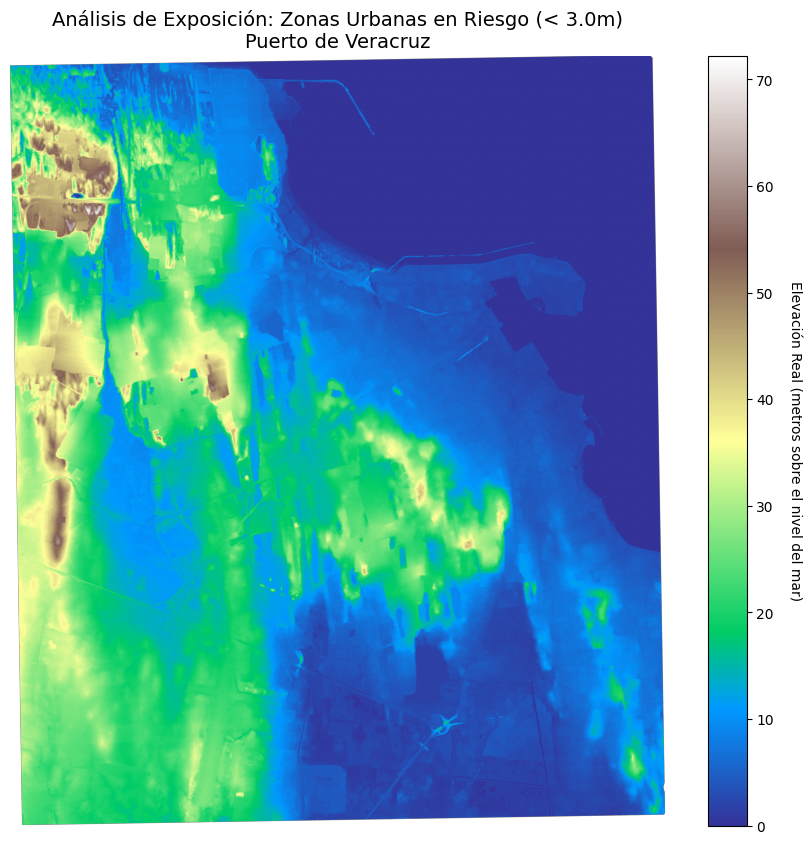

Píxeles urbanos detectados en zona de riesgo: 0


In [4]:
# ... (mantener el código de procesamiento anterior)

plt.figure(figsize=(14, 10))

# 1. Graficamos la elevación y guardamos el objeto en 'img_dem'
# Usamos vmin=0 para que la escala sea clara desde el nivel del mar
img_dem = plt.imshow(dem_cleaned, cmap='terrain', vmin=0, vmax=np.nanmax(dem_cleaned))

# 2. Superponemos el riesgo urbano con un color sólido (ej. Rojo intenso)
# Usamos una máscara para que solo se pinte donde el valor es 1
mask_riesgo = np.where(riesgo_urbano == 1, 1, np.nan)
plt.imshow(mask_riesgo, cmap='Reds_r', interpolation='none', alpha=0.8)

# 3. VINCULAR LA BARRA DE COLORES AL DEM (img_dem)
cbar = plt.colorbar(img_dem, fraction=0.046, pad=0.04)
cbar.set_label('Elevación Real (metros sobre el nivel del mar)', rotation=270, labelpad=20)

plt.title(f'Análisis de Exposición: Zonas Urbanas en Riesgo (< {umbral_inundacion}m)\nPuerto de Veracruz', fontsize=14)
plt.axis('off')
plt.show()

# Verificación de datos en consola
print(f"Píxeles urbanos detectados en zona de riesgo: {np.sum(riesgo_urbano)}")

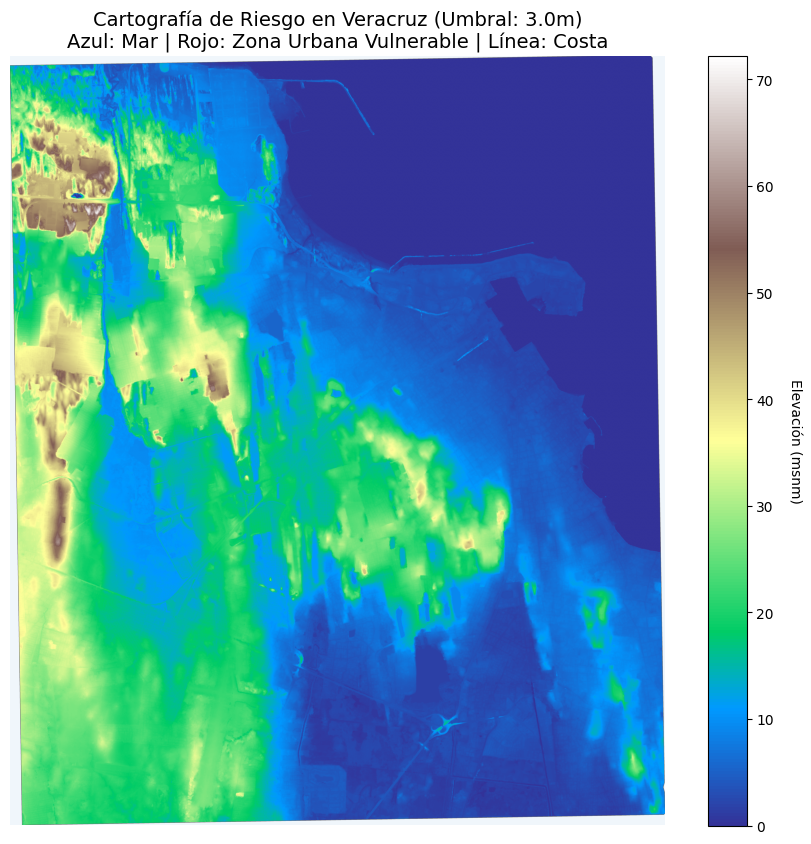

In [4]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import binary_dilation

# 1. Cargar datos
with rasterio.open('CEM_Veracruz_1_5m_FINAL_merged.tif') as dem_src:
    dem = dem_src.read(1)
    # Identificar el mar basado en el valor NoData del INEGI
    nodata_mask = (dem < -10) # El mar suele tener valores extremadamente bajos
    dem_cleaned = np.where(nodata_mask, np.nan, dem)

with rasterio.open('Capa_Urbana_Alineada.tif') as urban_src:
    urban = urban_src.read(1)

# 2. Definir la línea de costa (separación mar/tierra)
# Usamos una dilatación binaria para encontrar el borde de la máscara de tierra
tierra = ~nodata_mask
borde = binary_dilation(nodata_mask) & tierra

# 3. Cálculo de riesgo
umbral_inundacion = 3.0
riesgo_urbano = np.where((urban > 0) & (dem_cleaned <= umbral_inundacion), 1, 0)

# 4. Visualización
plt.figure(figsize=(14, 10))

# Capa 1: El Mar (Fondo azul claro)
plt.imshow(nodata_mask, cmap='Blues', vmin=0, vmax=5, alpha=0.3)

# Capa 2: Topografía de Tierra
img_dem = plt.imshow(dem_cleaned, cmap='terrain', vmin=0, vmax=np.nanmax(dem_cleaned))

# Capa 3: Línea de Costa (Negro fino)
plt.imshow(np.where(borde, 1, np.nan), cmap='binary', alpha=0.8)

# Capa 4: Riesgo Urbano (Rojo)
mask_riesgo = np.where(riesgo_urbano == 1, 1, np.nan)
plt.imshow(mask_riesgo, cmap='Reds_r', interpolation='none', alpha=0.9)

# Configuración de escala y títulos
cbar = plt.colorbar(img_dem, fraction=0.046, pad=0.04)
cbar.set_label('Elevación (msnm)', rotation=270, labelpad=20)

plt.title(f'Cartografía de Riesgo en Veracruz (Umbral: {umbral_inundacion}m)\nAzul: Mar | Rojo: Zona Urbana Vulnerable | Línea: Costa', fontsize=14)
plt.axis('off')
plt.show()

In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar datos (asegurando que los nombres coincidan con tu entorno actual)
archivo_maestro = 'CEM_Veracruz_1_5m_FINAL_merged.tif'
archivo_infra = 'capa_infraestructura.tif'
archivo_urbano = 'Capa_Urbana_Alineada.tif'

with rasterio.open(archivo_maestro) as master:
    dem = master.read(1)
    dem_cleaned = np.where(dem < -10, np.nan, dem)

    # 2. Alinear Vialidades
    with rasterio.open(archivo_infra) as infra_src:
        vialidades = np.zeros((master.height, master.width), dtype='float32')
        reproject(
            source=rasterio.band(infra_src, 1),
            destination=vialidades,
            src_transform=infra_src.transform,
            src_crs=infra_src.crs,
            dst_transform=master.transform,
            dst_crs=master.crs,
            resampling=Resampling.nearest
        )

# 3. Cargar Capa Urbana
with rasterio.open(archivo_urbano) as urb_src:
    urban = urb_src.read(1)

# 4. Cálculo de Riesgo Urbano (Umbral 3.0m)
umbral = 3.0
riesgo_urbano = np.where((urban > 0) & (dem_cleaned <= umbral), 1, 0)

# 5. Visualización de Alto Contraste
plt.figure(figsize=(15, 12), facecolor='white')

# Capa Base: Topografía (Aumentamos la opacidad para contraste)
img_dem = plt.imshow(dem_cleaned, cmap='terrain', vmin=0, vmax=72, alpha=0.8)

# Capa de Riesgo: Transparente (Alpha bajo para que no oculte la textura del terreno)
riesgo_mask = np.where(riesgo_urbano == 1, 1, np.nan)
plt.imshow(riesgo_mask, cmap='Reds', interpolation='none', alpha=0.4)

# Capa de Vialidades: Opaca y Vibrante (Alpha alto para resaltar sobre el riesgo)
# Usamos 'autumn_r' para un naranja/amarillo sólido
vialidades_mask = np.where(vialidades > 0, 1, np.nan)
plt.imshow(vialidades_mask, cmap='autumn_r', interpolation='none', alpha=1.0)

# Mar: Azul sólido para definir el límite costero
mar_mask = np.where(dem < -10, 1, np.nan)
plt.imshow(mar_mask, cmap='Blues', vmin=0, vmax=2, alpha=0.5)

# Detalles Estéticos
cbar = plt.colorbar(img_dem, fraction=0.046, pad=0.04)
cbar.set_label('Elevación (msnm)', fontsize=12)

plt.title(f'Análisis de Conectividad y Riesgo - Puerto de Veracruz\nResaltado: Vialidades (Amarillo) sobre Zonas de Riesgo (Rojo Transparente)',
          fontsize=16, fontweight='bold', pad=20)
plt.axis('off')

plt.show()

print(f"Visualización generada con éxito para la Etapa E3.")

In [1]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import os # Importamos os para la verificación de archivos

def ajustar_edafologia(archivo_maestro, archivo_eda, nombre_salida):
    # Verificar si el archivo maestro existe antes de intentar abrirlo
    if not os.path.exists(archivo_maestro):
        print(f"❌ Error: No se encontró el archivo maestro '{archivo_maestro}'.")
        print(f"Archivos disponibles en la carpeta actual: {os.listdir('.')}")
        return # Salir de la función si el archivo no existe

    # 1. Abrir el mosaico de elevación para obtener la georeferencia de 1.5m
    with rasterio.open(archivo_maestro) as master:
        # 2. Abrir el archivo de edafología (e1403.tif según tu imagen)
        with rasterio.open(archivo_eda) as eda_src:
            # Crear matriz vacía con dimensiones exactas del maestro
            eda_data = np.zeros((master.height, master.width), dtype='float32')

            print(f"Alineando {archivo_eda} con el mosaico de Veracruz...")

            # 3. Reproyectar y ajustar dimensiones
            # Usamos Resampling.nearest para no alterar las categorías de suelo
            reproject(
                source=rasterio.band(eda_src, 1),
                destination=eda_data,
                src_transform=eda_src.transform,
                src_crs=eda_src.crs,
                dst_transform=master.transform,
                dst_crs=master.crs,
                resampling=Resampling.nearest
            )

            # 4. Actualizar metadatos y guardar
            out_meta = master.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "dtype": 'float32',
                "count": 1,
                "nodata": 0
            })

            with rasterio.open(nombre_salida, 'w', **out_meta) as dest:
                dest.write(eda_data, 1)

    print(f"✅ Archivo ajustado generado: {nombre_salida}")

# --- Ejecución ---
# Usando los nombres de tus archivos
ajustar_edafologia('CEM_Veracruz_1_5m_FINAL_merged.tif', 'e1403.tif', 'Edafologia_Alineada_1_5m.tif')

Alineando e1403.tif con el mosaico de Veracruz...
✅ Archivo ajustado generado: Edafologia_Alineada_1_5m.tif


INTEGRACION EDAFOLOGIA

In [2]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

# 1. Definir los archivos (ajusta los nombres si es necesario)
archivo_maestro = 'CEM_Veracruz_1_5m_FINAL_merged.tif'
archivo_edafologia = 'e1403.tif'
salida_nombre = 'Edafologia_Alineada_1_5m.tif'

print("🔄 Iniciando alineación de la capa de edafología...")

with rasterio.open(archivo_maestro) as master:
    # Obtenemos los metadatos y la georeferencia del mosaico de 1.5m
    master_meta = master.meta.copy()

    with rasterio.open(archivo_edafologia) as eda_src:
        # Creamos una matriz vacía con las dimensiones exactas del maestro
        # Usamos float32 para mantener la precisión de los valores de clase
        eda_alineada = np.zeros((master.height, master.width), dtype='float32')

        # 2. Reproyectar y ajustar dimensiones
        # Es CRÍTICO usar Resampling.nearest para datos categóricos (tipos de suelo)
        reproject(
            source=rasterio.band(eda_src, 1),
            destination=eda_alineada,
            src_transform=eda_src.transform,
            src_crs=eda_src.crs,
            dst_transform=master.transform,
            dst_crs=master.crs,
            resampling=Resampling.nearest
        )

        # 3. Actualizar metadatos para el nuevo archivo
        master_meta.update({
            "driver": "GTiff",
            "dtype": 'float32',
            "count": 1,
            "nodata": 0
        })

        # 4. Guardar la edafología ajustada
        with rasterio.open(salida_nombre, 'w', **master_meta) as dest:
            dest.write(eda_alineada, 1)

print(f"✅ Proceso completado. Archivo generado: {salida_nombre}")
print(f"Dimensiones finales: {eda_alineada.shape[1]}x{eda_alineada.shape[0]}")

🔄 Iniciando alineación de la capa de edafología...
✅ Proceso completado. Archivo generado: Edafologia_Alineada_1_5m.tif
Dimensiones finales: 8012x9423


Capas de Infraestructura y Urbana

In [3]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

def sincronizar_capas(archivo_maestro, capas_a_procesar):
    with rasterio.open(archivo_maestro) as master:
        master_meta = master.meta.copy()
        for archivo_ent, archivo_sal in capas_a_procesar.items():
            with rasterio.open(archivo_ent) as src:
                data_alin = np.zeros((master.height, master.width), dtype='float32')
                reproject(
                    source=rasterio.band(src, 1),
                    destination=data_alin,
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=master.transform,
                    dst_crs=master.crs,
                    resampling=Resampling.nearest
                )
                master_meta.update(dtype='float32', count=1, nodata=0)
                with rasterio.open(archivo_sal, 'w', **master_meta) as dest:
                    dest.write(data_alin, 1)
                print(f"✅ Sincronizado: {archivo_sal}")

# Definir archivos de entrada y salida
tareas = {
    'capa_urbana.tif': 'Capa_Urbana_Alineada.tif',
    'capa_infraestructura.tif': 'Infraestructura_Alineada.tif'
}

sincronizar_capas('CEM_Veracruz_1_5m_FINAL_merged.tif', tareas)

✅ Sincronizado: Capa_Urbana_Alineada.tif
✅ Sincronizado: Infraestructura_Alineada.tif


Riesgo + Suelo + Infraestructura

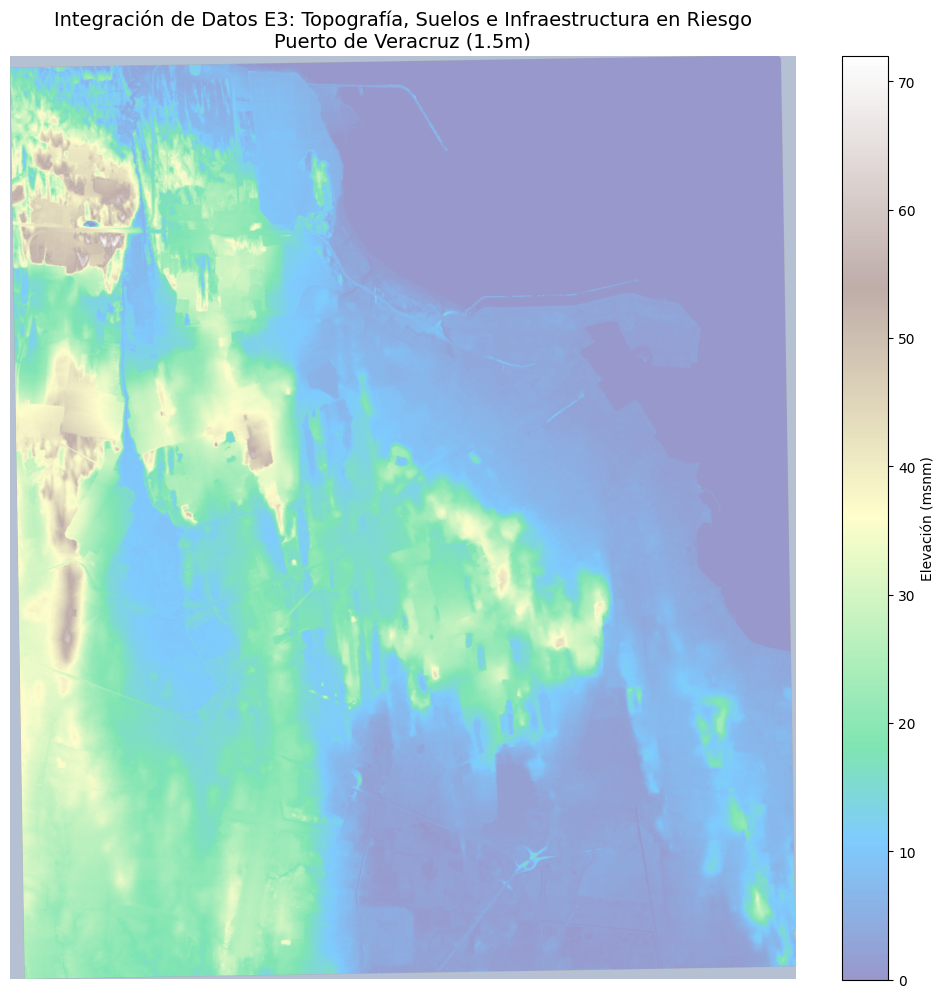

✅ Visualización generada correctamente con los nombres de archivo actualizados.


In [5]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

# Nombres corregidos según tu panel de archivos
archivo_dem = 'CEM_Veracruz_1_5m_FINAL_merged.tif'
archivo_edafologia = 'Edafologia_Alineada_1_5m.tif' # Corregido de 1.5m a 1_5m
archivo_infra = 'Infraestructura_Alineada.tif'
archivo_urbano = 'Capa_Urbana_Alineada.tif'

# Cargar capas alineadas
with rasterio.open(archivo_dem) as dem_src:
    dem = dem_src.read(1)
    dem_cleaned = np.where(dem < -10, np.nan, dem)

with rasterio.open(archivo_edafologia) as eda_src:
    eda = eda_src.read(1)

with rasterio.open(archivo_infra) as infra_src:
    infra = infra_src.read(1)

with rasterio.open(archivo_urbano) as urb_src:
    urban = urb_src.read(1)

# Cálculo de riesgo (Umbral 3.0m)
riesgo_urbano = np.where((urban > 0) & (dem_cleaned <= 3.0), 1, 0)

# Visualización
plt.figure(figsize=(15, 12))

# 1. Mar y Edafología (Fondo)
plt.imshow(dem < -10, cmap='Blues', alpha=0.3)
plt.imshow(np.where(eda > 0, eda, np.nan), cmap='tab20b', alpha=0.3)

# 2. Topografía
img_dem = plt.imshow(dem_cleaned, cmap='terrain', vmin=0, vmax=72, alpha=0.5)

# 3. Riesgo Urbano (Rojo)
plt.imshow(np.where(riesgo_urbano == 1, 1, np.nan), cmap='Reds', alpha=0.6)

# 4. Vialidades (Amarillo vibrante)
plt.imshow(np.where(infra > 0, 1, np.nan), cmap='autumn_r', alpha=1.0)

plt.title('Integración de Datos E3: Topografía, Suelos e Infraestructura en Riesgo\nPuerto de Veracruz (1.5m)', fontsize=14)
plt.colorbar(img_dem, label='Elevación (msnm)', fraction=0.046, pad=0.04)
plt.axis('off')
plt.show()

print("✅ Visualización generada correctamente con los nombres de archivo actualizados.")

In [6]:
import rasterio
import numpy as np

# 1. Definir los archivos alineados que ya generamos
capas = [
    'CEM_Veracruz_1_5m_FINAL_merged.tif', # Banda 1: Elevación
    'Edafologia_Alineada_1_5m.tif',       # Banda 2: Suelos
    'Infraestructura_Alineada.tif',       # Banda 3: Vialidades
    'Capa_Urbana_Alineada.tif'            # Banda 4: Mancha Urbana
]

output_multicanal = 'Dataset_Veracruz_1_5m_Multicanal.tif'

print("📦 Empaquetando capas para PyTorch...")

with rasterio.open(capas[0]) as src:
    # Copiamos los metadatos pero actualizamos el conteo de bandas a 4
    meta_final = src.meta.copy()
    meta_final.update({
        "count": len(capas),
        "dtype": 'float32',
        "nodata": -9999
    })

    with rasterio.open(output_multicanal, 'w', **meta_final) as dest:
        for i, archivo in enumerate(capas, start=1):
            with rasterio.open(archivo) as s:
                banda = s.read(1)
                # Normalización básica: asegurar que los NoData sean consistentes
                banda_limpia = np.where((banda < -100) | (banda == 0), -9999, banda)
                dest.write(banda_limpia.astype('float32'), i)
                print(f"✅ Banda {i} añadida: {archivo}")

print(f"\n¡Dataset listo! Archivo generado: {output_multicanal}")

📦 Empaquetando capas para PyTorch...
✅ Banda 1 añadida: CEM_Veracruz_1_5m_FINAL_merged.tif
✅ Banda 2 añadida: Edafologia_Alineada_1_5m.tif
✅ Banda 3 añadida: Infraestructura_Alineada.tif
✅ Banda 4 añadida: Capa_Urbana_Alineada.tif

¡Dataset listo! Archivo generado: Dataset_Veracruz_1_5m_Multicanal.tif
